In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import imgaug as ia
import imgaug.augmenters as iaa

ia.seed(1)

In [2]:
seq = iaa.Sequential([
    iaa.Fliplr(0.5), # horizontal flips
    iaa.Crop(percent=(0, 0.1)), # random crops
    # Small gaussian blur with random sigma between 0 and 0.5.
    # But we only blur about 50% of all images.
    iaa.Sometimes(
        0.5,
        iaa.GaussianBlur(sigma=(0, 0.5))
    ),
    # Strengthen or weaken the contrast in each image.
    iaa.LinearContrast((0.75, 1.5)),
    # Add gaussian noise.
    # For 50% of all images, we sample the noise once per pixel.
    # For the other 50% of all images, we sample the noise per pixel AND
    # channel. This can change the color (not only brightness) of the
    # pixels.
    iaa.AdditiveGaussianNoise(loc=0, scale=(0.0, 0.05*255), per_channel=0.5),
    # Make some images brighter and some darker.
    # In 20% of all cases, we sample the multiplier once per channel,
    # which can end up changing the color of the images.
    iaa.Multiply((0.8, 1.2), per_channel=0.01),
    # Apply affine transformations to each image.
    # Scale/zoom them, translate/move them, rotate them and shear them.
    iaa.Affine(
        scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
        translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)},
        rotate=(-25, 25),
        shear=(-8, 8)
    )
], random_order=True) # apply augmenters in random order

In [8]:
labels = ['chalk','charcoal','sage','sand','sky']
N = 100
path ="gg/"
typ = 'train/'

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')
        
for label in labels:
    img = cv2.imread(os.path.join(path,label,f'{label}_0.jpg'))
    dim=227
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    print(img.shape)

    # The array has shape (32, 64, 64, 3) and dtype uint8. example: ia.quokka(size=(64, 64))
    images = np.array([ img for _ in range(N)],dtype=np.uint8)

    images_aug = seq(images=images)

    if not os.path.isdir(f'{typ}{label}'):
        os.mkdir(f'{typ}{label}')

    for i in range(N):
        cv2.imwrite(f'{typ}{label}/{label}_{i}.jpg',images_aug[i])

(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)


In [9]:
labels = ['chalk','charcoal','sage','sand','sky']
N = 10
path ="gg/"
typ = 'test/'

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')
        
for label in labels:
    img = cv2.imread(os.path.join(path,label,f'{label}_0.jpg'))
    dim=227
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    print(img.shape)

    # The array has shape (32, 64, 64, 3) and dtype uint8. example: ia.quokka(size=(64, 64))
    images = np.array([ img for _ in range(N)],dtype=np.uint8)

    images_aug = seq(images=images)

    if not os.path.isdir(f'{typ}{label}'):
        os.mkdir(f'{typ}{label}')

    for i in range(N):
        cv2.imwrite(f'{typ}{label}/{label}_{i}.jpg',images_aug[i])

(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)
(227, 227, 3)


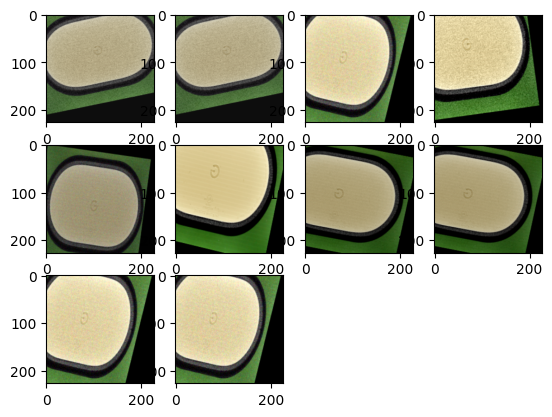

In [10]:
num = 10
col=4
imgs = list(np.random.choice(len(images_aug),num))
for i in range(num):
    plt.subplot(num/col if num%col==0 else int(num/col)+1,col,i+1)
    plt.imshow(images_aug[imgs[i]])

# 2.2 SVM

In [20]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [21]:
IMG_SIZE=100
path ="train"

In [38]:
labels = os.listdir(os.path.join(path))
print(labels)
dic = {}
for k,l in enumerate(labels):
    dic[k]=l

['sky', 'charcoal', 'sage', 'chalk', 'sand']


In [39]:
dic

{0: 'sky', 1: 'charcoal', 2: 'sage', 3: 'chalk', 4: 'sand'}

In [23]:
X = []
y = [] #0,1,2,3,4
for k,label in enumerate(labels):
    for i in os.listdir(os.path.join(path,label)):
        img = cv2.imread(os.path.join(path,label,i))
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        X.append(img)
        y.append(k)

In [24]:
X = np.array(X).reshape(len(X),-1)
X.shape

(500, 30000)

In [25]:
y[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [26]:
# shuffle
X,y = shuffle(X,y)

In [27]:
y[:10]

[0, 4, 3, 1, 4, 3, 4, 2, 1, 3]

In [28]:
# norm
X = X/255.0

In [29]:
y = np.array(y)
print(y.shape)

(500,)


In [30]:
# split
X_train, X_val, y_train, y_val = train_test_split(X,y)

In [31]:
from sklearn.svm import SVC
svc = SVC(kernel='linear',gamma='auto')
svc.fit(X_train, y_train)

SVC(gamma='auto', kernel='linear')

In [32]:
y2 = svc.predict(X_val)

In [33]:
# calc accuracy
print("Accuracy on unknown data is",accuracy_score(y_val,y2))

Accuracy on unknown data is 0.984


In [35]:
print("Accuracy on unknown data is",classification_report(y_val,y2))

Accuracy on unknown data is               precision    recall  f1-score   support

           0       1.00      0.97      0.98        31
           1       1.00      1.00      1.00        26
           2       0.95      1.00      0.97        18
           3       1.00      0.95      0.98        22
           4       0.97      1.00      0.98        28

    accuracy                           0.98       125
   macro avg       0.98      0.98      0.98       125
weighted avg       0.98      0.98      0.98       125



# predict

Text(0.5, 1.0, 'pred: charcoal (charcoal)')

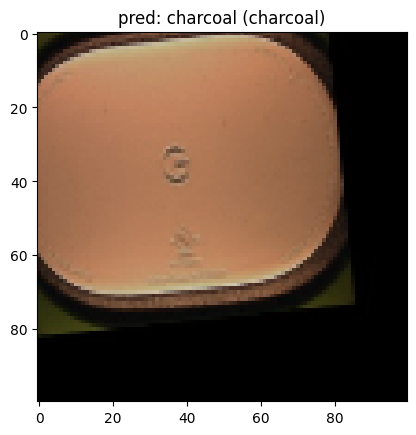

In [125]:
# random test
path = 'test'
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
i = random.choice(imgs)

img = cv2.imread(os.path.join(path,label,i))
img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
plt.imshow(img)
img = img/255.0
img = img.reshape(1,-1)
img.shape
y= svc.predict(img)
plt.title("pred: " + label +" (" + dic[int(y)] + ")")

Text(0.5, 1.0, 'pred: charcoal (charcoal)')

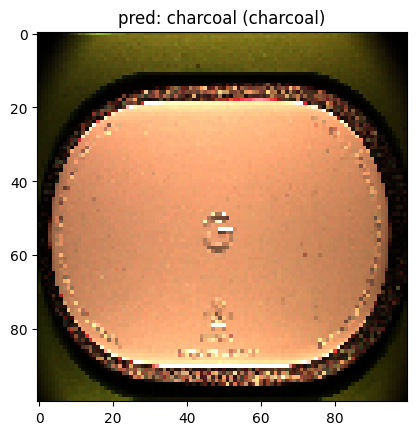

In [136]:
# random test
path = 'gg'
labels = os.listdir(path)
label = random.choice(labels)
imgs = os.listdir(os.path.join(path,label))
i = random.choice(imgs)

img = cv2.imread(os.path.join(path,label,i))
img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
plt.imshow(img)
img = img/255.0
img = img.reshape(1,-1)
img.shape
y= svc.predict(img)
plt.title("pred: " + label +" (" + dic[int(y)] + ")")

# references

[imgaug](https://github.com/aleju/imgaug)

[color classification](https://github.com/beerboaa/Color-Classification-CNN)

[kaggle color classification](https://www.kaggle.com/datasets/ayanzadeh93/color-classification/code)

[color recognition](https://github.com/ahmetozlu/color_recognition)